# CPP with protein language model embeddings and AlphaFold structures

CPP compares a **test group** against a **reference group** by averaging a per-residue value over the positions a feature spans. That value does not have to come from an amino acid scale: any per-residue tensor in `[0, 1]` works, so **learned** channels (protein language model (PLM) embeddings) and **structural** channels (AlphaFold models) ride the same `Part-Split-Scale` grammar and produce the same `df_feat`. This tutorial shows the recommended way to feed both sources into `CPP.run_num`, how to fuse them, and how to paint the resulting signature back onto the AlphaFold model.

The recipe is the same for every per-residue source and has four steps:

1. **Encode** the source into a `dict_num`, a mapping `{entry: (L, D)}` with `L` = sequence length, `D` = number of channels, values in `[0, 1]`.
2. **Name the channels** with `build_scales` / `build_cat`. The resulting `df_scales` / `df_cat` give each of the `D` channels an id and a category; `CPP.run_num` uses them only for naming and for the category-aware redundancy filter, never as a value source.
3. **Slice** sequences and tensors with the same TMD-JMD boundaries via `NumericalFeature.get_parts`, which returns `(df_parts, dict_num_parts)`.
4. **Run** `CPP(df_parts, df_scales, df_cat).run_num(dict_num_parts, labels)`.

We use the bundled gamma-secretase set (`DOM_GSEC`, substrates vs. non-substrates), whose `entry` column holds UniProt accessions. That is what both the embedding path (sequence in, embedding out) and the AlphaFold path (accession in, model out) need. The setup requires `pip install "aaanalysis[pro,embed]"`, the `mkdssp` binary on your `PATH`, and network access for the Hugging Face Hub and the AlphaFold Database.

In [1]:
import warnings
import tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa

aa.options["verbose"] = False
aa.plot_settings()
# Biopython's DSSP wrapper probes every .pdb as mmCIF first; silence that one benign warning.
warnings.filterwarnings("ignore", message="parse error at line 1")

df_seq = aa.load_dataset(name="DOM_GSEC", n=10)   # 10 substrates (label=1) + 10 non-substrates (label=0)
labels = df_seq["label"].to_list()
work_dir = Path(tempfile.mkdtemp())               # point this at a persistent project folder in real work


def add_importance(df_feat, dict_num_parts, df_parts, df_scales, labels):
    # Rebuild the per-protein feature matrix from the very tensors CPP used, then rank the
    # selected features with tree-based models: the standard CPP follow-up, also in numerical mode.
    X = aa.NumericalFeature.feature_matrix(features=df_feat, dict_num_parts=dict_num_parts,
                                           df_parts=df_parts, df_scales=df_scales)
    tm = aa.TreeModel(random_state=42, verbose=False).fit(X, labels=labels)
    return tm.add_feat_importance(df_feat=df_feat, drop=True)


aa.display_df(df_seq[["entry", "gene", "label", "tmd_start", "tmd_stop"]], n_rows=10, show_shape=True)

DataFrame shape: (20, 5)


,entry,gene,label,tmd_start,tmd_stop
1,Q14802,FXYD3,0,37,59
2,Q86UE4,MTDH,0,50,72
3,Q969W9,PMEPA1,0,41,63
4,P53801,PTTG1IP,0,97,119
5,Q8IUW5,RELL1,0,59,81
6,P01135,TGFA,0,99,121
7,O43914,TYROBP,0,42,64
8,P05556,ITGB1,0,729,751
9,P16234,PDGFRA,0,527,549
10,P50895,BCAM,0,549,571


## 1. Embeddings: from a PLM to a CPP signature

Three decisions matter here:

- **Model.** `esm2_t12_35M` (480 channels) is the default and the best size-to-quality trade-off on a CPU. Use `esm2_t6_8M` for a quick test on large corpora, `esm2_t33_650M` or `prott5_xl_u50` when a GPU is available, and `prostt5` when you want structure-aware embeddings. Embedding is the expensive step, so **compute once and cache** the raw `(L, D)` arrays; everything downstream is cheap.
- **Normalisation.** Raw embeddings are unbounded, but `CPP.run_num` and its `max_std_test` pre-filter are calibrated for `[0, 1]`. `encode` fits one normaliser per channel over the whole corpus; `method="quantile"` uses robust percentiles so a few extreme residues do not squash the rest. The fitted parameters live in `embp.norm_params_`, so you can reproduce the identical transform later.
- **Channel names and categories.** `build_scales` names the channels (`dim_0` ... `dim_479`) and `build_cat` clusters correlated channels into pseudo-categories with AAclust. Passing that `df_cat` to `CPP` lets the redundancy filter treat correlated channels as one family, exactly as it treats AAontology categories on the sequence arm.

In [2]:
embp = aa.EmbeddingPreprocessor(verbose=False)
cache = work_dir / "esm2_t12_35M_residue.npz"
if not cache.exists():
    emb = embp.fetch_embeddings(df_seq=df_seq, mode="residue", model="esm2_t12_35M")
    np.savez(cache, **emb)                       # raw {entry: (L, D)} arrays, computed once
emb = dict(np.load(cache))

dict_emb = embp.encode(df_seq=df_seq, embeddings=emb, method="quantile")   # -> [0, 1] per channel
df_scales_emb = embp.build_scales(df_seq=df_seq, dict_num=dict_emb)        # names dim_0 ... dim_479
df_cat_emb = embp.build_cat(df_scales=df_scales_emb, random_state=42)     # clusters channels into categories
print(f"D = {df_scales_emb.shape[1]} embedding channels; stored normaliser keys: {list(embp.norm_params_)}")
aa.display_df(df_cat_emb, n_rows=5, show_shape=True)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

/var/folders/sv/65tlch_10198qgmpwcp6408r0000gn/T/ipykernel_76025/2040070337.py:9: UserWarning: Pseudo-scales are dataset-dependent (averaged over df_seq). For reproducible cross-dataset comparison, compute them once on a fixed reference corpus and reuse the resulting df_scales.
  df_scales_emb = embp.build_scales(df_seq=df_seq, dict_num=dict_emb)        # names dim_0 ... dim_479


D = 480 embedding channels; stored normaliser keys: ['method', 'lo', 'hi', 'clip']
DataFrame shape: (480, 5)


,scale_id,category,subcategory,scale_name,scale_description
1,dim_0,Embeddings,Embeddings_cat32_subcat8,dim_0,
2,dim_1,Embeddings,Embeddings_cat20_subcat5,dim_1,
3,dim_2,Embeddings,Embeddings_cat55_subcat2,dim_2,
4,dim_3,Embeddings,Embeddings_cat5_subcat9,dim_3,
5,dim_4,Embeddings,Embeddings_cat1_subcat0,dim_4,


In [3]:
df_parts_emb, dnp_emb = aa.NumericalFeature.get_parts(df_seq=df_seq, dict_num=dict_emb)
cpp_emb = aa.CPP(df_parts=df_parts_emb, df_scales=df_scales_emb, df_cat=df_cat_emb, verbose=False)
df_feat_emb = cpp_emb.run_num(dict_num_parts=dnp_emb, labels=labels, n_filter=50, n_jobs=1)
df_feat_emb = add_importance(df_feat_emb, dnp_emb, df_parts_emb, df_scales_emb, labels)
aa.display_df(df_feat_emb, n_rows=10, show_shape=True)

DataFrame shape: (50, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"JMD_N_TMD_N-Pat...n(C,2,5)-dim_75",Embeddings,Embeddings_cat18_subcat69,dim_75,,0.500000,0.158000,0.158000,0.069000,0.066000,0.000157,0.045189,"16,19",4.406000,0.840000
2,"TMD-Pattern(N,8,11)-dim_75",Embeddings,Embeddings_cat18_subcat69,dim_75,,0.500000,0.158000,0.158000,0.069000,0.066000,0.000157,0.045189,"18,21",4.428000,0.496000
3,"TMD_C_JMD_C-Pat...,1,4,8)-dim_101",Embeddings,Embeddings_cat72_subcat94,dim_101,,0.500000,0.149000,-0.149000,0.048000,0.047000,0.000157,0.045189,"33,37,40",4.568000,1.028000
4,"TMD-Pattern(C,3,7)-dim_403",Embeddings,Embeddings_cat7_subcat382,dim_403,,0.500000,0.144000,-0.144000,0.044000,0.065000,0.000157,0.045189,"24,28",4.437000,1.759000
5,"TMD_C_JMD_C-Pat...(N,5,9)-dim_403",Embeddings,Embeddings_cat7_subcat382,dim_403,,0.500000,0.144000,-0.144000,0.044000,0.065000,0.000157,0.045189,"25,29",3.774000,1.130000
6,"JMD_N_TMD_N-Seg...nt(1,3)-dim_198",Embeddings,Embeddings_cat1_subcat186,dim_198,,0.500000,0.111000,-0.111000,0.032000,0.065000,0.000157,0.045189,"1,2,3,4,5,6",3.301000,1.469000
7,"TMD_C_JMD_C-Pat...n(C,2,5)-dim_85",Embeddings,Embeddings_cat13_subcat79,dim_85,,0.490000,0.268000,-0.268000,0.093000,0.106000,0.000212,0.045189,"36,39",3.024000,0.445000
8,"TMD-Segment(3,3)-dim_403",Embeddings,Embeddings_cat7_subcat382,dim_403,,0.490000,0.136000,-0.136000,0.034000,0.042000,0.000212,0.045189,"24,25,26,27,28,29,30",4.712000,1.775000
9,"TMD_C_JMD_C-Pat...6,10,14)-dim_98",Embeddings,Embeddings_cat68_subcat92,dim_98,,0.480000,0.216000,0.216000,0.061000,0.099000,0.000285,0.045189,"27,31,35",2.609000,0.551000
10,"TMD_C_JMD_C-Pat...(C,2,5)-dim_288",Embeddings,Embeddings_cat9_subcat272,dim_288,,0.480000,0.207000,-0.207000,0.076000,0.070000,0.000285,0.045189,"36,39",1.937000,0.442000


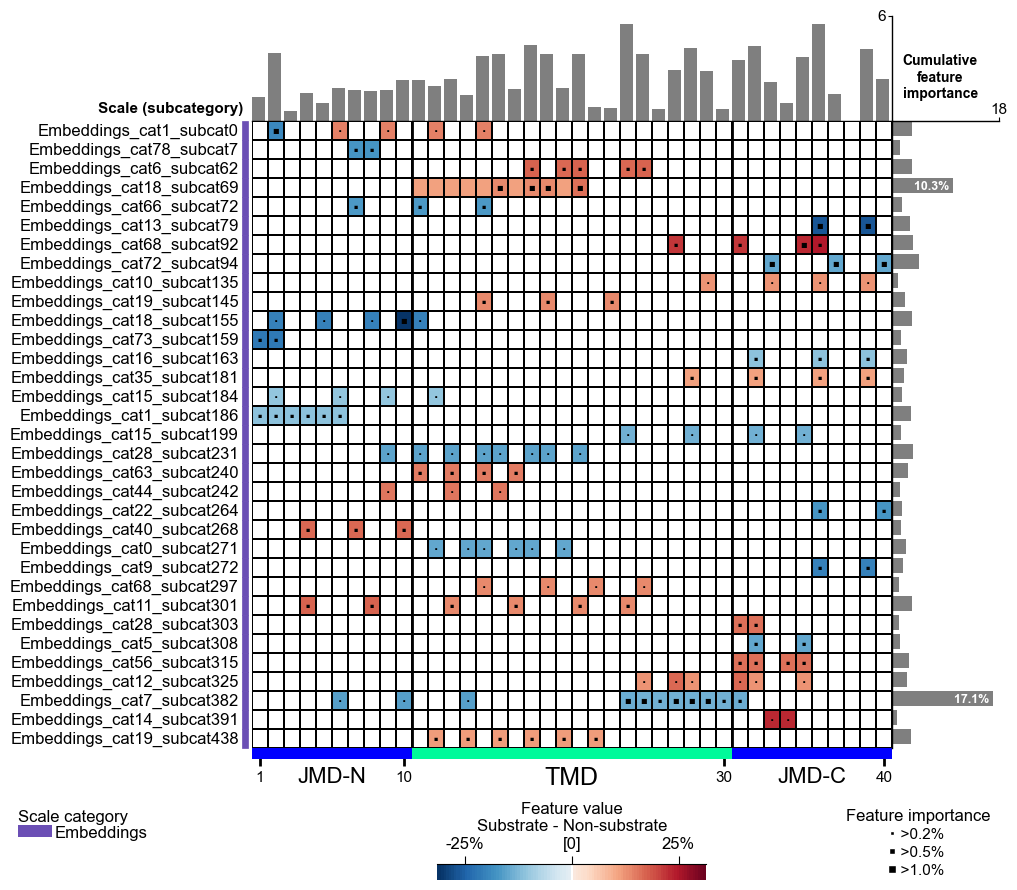

In [4]:
# The feature map needs the embedding's own channel names and pseudo-categories.
aa.CPPPlot(df_scales=df_scales_emb, df_cat=df_cat_emb, jmd_n_len=10, jmd_c_len=10).feature_map(
    df_feat=df_feat_emb, name_test="Substrate", name_ref="Non-substrate")
plt.tight_layout()
plt.show()

## 2. AlphaFold structures: from a model to a CPP signature

`fetch_alphafold` downloads each entry's model and its Predicted Aligned Error (PAE) sidecar into one folder, under the file names the encoders resolve. `StructurePreprocessor.encode` then takes a single mixed feature list and routes every key to its backend (DSSP, PDB atom records, PAE) before merging the results into one `dict_num`. A good default channel set for AlphaFold models:

- `ss3` and `rasa` (DSSP): three-state secondary structure and relative accessible surface area, the local geometry.
- `plddt`: AlphaFold's per-residue confidence. Regions below about 70 are usually disordered in isolation, so every other channel is unreliable there; carrying `plddt` along lets CPP and you see where that is.
- `pae_row_mean`: how well a residue is placed relative to the rest of the chain, a domain-level confidence signal that `plddt` alone does not capture.

Not every accession has an AlphaFold model, and DSSP can fail on a file. Use `on_failure="drop"` together with `return_df=True`, then **re-derive `labels` from the returned frame** so labels and tensors stay aligned.

In [5]:
strp = aa.StructurePreprocessor(verbose=False)
af_dir = work_dir / "alphafold"
strp.fetch_alphafold(df_seq=df_seq, out_folder=af_dir)      # <entry>.pdb + PAE json per entry; skips existing files

STRUCT_FEATURES = ["ss3", "rasa", "plddt", "pae_row_mean"]
dict_str, df_seq_str = strp.encode(df_seq=df_seq, features=STRUCT_FEATURES, pdb_folder=af_dir,
                                   pae_folder=af_dir, on_failure="drop", return_df=True)
df_seq_str = df_seq_str.reset_index(drop=True)
labels_str = df_seq_str["label"].to_list()                  # labels re-aligned to the kept entries
df_scales_str = strp.build_scales(df_seq=df_seq_str, dict_num=dict_str, features=STRUCT_FEATURES)
df_cat_str = strp.build_cat(features=STRUCT_FEATURES)
print(f"{len(dict_str)}/{len(df_seq)} entries with a usable AlphaFold model; D = {df_scales_str.shape[1]} channels")
aa.display_df(df_cat_str, n_rows=10, show_shape=True)

20/20 entries with a usable AlphaFold model; D = 6 channels
DataFrame shape: (6, 5)


/var/folders/sv/65tlch_10198qgmpwcp6408r0000gn/T/ipykernel_76025/3557379640.py:10: UserWarning: Pseudo-scales are dataset-dependent (averaged over df_seq + dict_num). For reproducible cross-dataset comparison, compute them once on a fixed reference corpus and reuse the resulting df_scales.
  df_scales_str = strp.build_scales(df_seq=df_seq_str, dict_num=dict_str, features=STRUCT_FEATURES)


,scale_id,category,subcategory,scale_name,scale_description
1,ss_helix,Structure,Secondary structure (3-state),ss_helix,Structure/Secon...cture (3-state)
2,ss_strand,Structure,Secondary structure (3-state),ss_strand,Structure/Secon...cture (3-state)
3,ss_coil,Structure,Secondary structure (3-state),ss_coil,Structure/Secon...cture (3-state)
4,rasa,Structure,Relative ASA (Tien),rasa,Structure/Relative ASA (Tien)
5,plddt,Structure,AlphaFold pLDDT (raw),plddt,Structure/Alpha...old pLDDT (raw)
6,pae_mean,Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean)


In [6]:
df_parts_str, dnp_str = aa.NumericalFeature.get_parts(df_seq=df_seq_str, dict_num=dict_str)
cpp_str = aa.CPP(df_parts=df_parts_str, df_scales=df_scales_str, df_cat=df_cat_str, verbose=False)
df_feat_str = cpp_str.run_num(dict_num_parts=dnp_str, labels=labels_str, n_filter=50, n_jobs=1)
df_feat_str = add_importance(df_feat_str, dnp_str, df_parts_str, df_scales_str, labels_str)
aa.display_df(df_feat_str, n_rows=10, show_shape=True)

DataFrame shape: (17, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD-Pattern(C,11,15)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.380000,0.172000,0.172000,0.143000,0.196000,0.004072,0.010057,"16,20",7.138000,1.450000
2,"TMD-Pattern(N,9,13)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.380000,0.172000,0.172000,0.143000,0.196000,0.004072,0.010057,"19,23",5.540000,0.739000
3,"TMD-Segment(6,8)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.380000,0.167000,0.167000,0.143000,0.188000,0.004072,0.010057,"23,24,25",6.865000,1.153000
4,"TMD_C_JMD_C-Pat...1,4,7)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.380000,0.166000,0.166000,0.138000,0.189000,0.004072,0.010057,"21,24,27",7.207000,1.170000
5,"TMD-Segment(6,14)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.370000,0.173000,0.173000,0.143000,0.198000,0.005159,0.010057,18,4.238000,0.879000
6,"TMD-Pattern(N,5...12,15)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.370000,0.170000,0.170000,0.143000,0.196000,0.005159,0.010057,"15,18,22,25",5.173000,1.396000
7,"TMD-Segment(6,7)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.360000,0.166000,0.166000,0.135000,0.185000,0.006502,0.010057,"25,26,27",4.351000,0.378000
8,"JMD_N_TMD_N-Pat...,8,11)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.360000,0.166000,0.166000,0.139000,0.195000,0.006502,0.010057,"10,13,17",4.415000,0.672000
9,"TMD-Segment(3,7)-pae_mean",Structure,AlphaFold PAE (row mean),pae_mean,Structure/Alpha... PAE (row mean),0.350000,0.171000,0.171000,0.143000,0.198000,0.008151,0.010525,"16,17,18",3.843000,0.497000
10,"JMD_N_TMD_N-Seg...ent(3,14)-plddt",Structure,AlphaFold pLDDT (raw),plddt,Structure/Alpha...old pLDDT (raw),0.340000,0.206000,-0.206000,0.195000,0.120000,0.010165,0.011839,"3,4",9.108000,0.831000


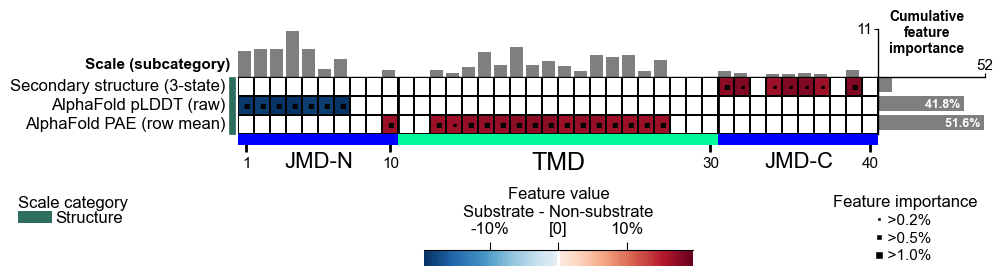

In [7]:
aa.CPPPlot(df_scales=df_scales_str, df_cat=df_cat_str, jmd_n_len=10, jmd_c_len=10).feature_map(
    df_feat=df_feat_str, name_test="Substrate", name_ref="Non-substrate")
plt.tight_layout()
plt.show()

## 3. Fusing both sources

`aa.combine_dict_nums` stacks per-residue tensors along the channel axis, and the `df_scales` / `df_cat` tables simply concatenate. Because the structure arm may have dropped entries, restrict the embedding tensor to the entries that have a structure first.

One caveat worth showing: the fused run ranks features across **all** channels. Here 480 embedding channels meet 6 structural ones, and on a set of 20 proteins the sheer number of embedding channels and splits makes it easy for an embedding feature to separate the groups perfectly by chance. The per-category tally below makes such dominance visible. When you see it, compare the arms separately (sections 1 and 2), pre-select embedding channels before fusing, and confirm the survivors with a validation protocol (P10) rather than trusting one run.

In [8]:
dict_fused = aa.combine_dict_nums([{e: dict_emb[e] for e in dict_str}, dict_str])   # D = 480 + 6
df_scales_fused = pd.concat([df_scales_emb, df_scales_str], axis=1)
df_cat_fused = pd.concat([df_cat_emb, df_cat_str], ignore_index=True)

df_parts_fused, dnp_fused = aa.NumericalFeature.get_parts(df_seq=df_seq_str, dict_num=dict_fused)
cpp_fused = aa.CPP(df_parts=df_parts_fused, df_scales=df_scales_fused, df_cat=df_cat_fused, verbose=False)
df_feat_fused = cpp_fused.run_num(dict_num_parts=dnp_fused, labels=labels_str, n_filter=50, n_jobs=1)
df_feat_fused = add_importance(df_feat_fused, dnp_fused, df_parts_fused, df_scales_fused, labels_str)

df_tally = (df_feat_fused.groupby("category")["abs_auc"]
            .agg(n_features="count", mean_abs_auc="mean").reset_index())
aa.display_df(df_tally, n_rows=10, show_shape=True)

DataFrame shape: (1, 3)


,category,n_features,mean_abs_auc
1,Embeddings,50,0.470400


## 4. Painting the signature onto the AlphaFold model

`CPPStructurePlot.map_structure` maps every feature in a `df_feat` to the residues it spans and paints a signed value onto the 3D cartoon (red raises, blue lowers the substrate call). At the group level a natural signed value is the feature importance signed by the direction of `mean_dif`; at the sample level you would pass the `feat_impact` column from `ShapModel`. Two geometry rules keep the paint on the right residues:

- `start` is the absolute residue number of the first JMD-N residue, so `tmd_start - jmd_n_len`.
- `tmd_len` is **this protein's** TMD length; passing `sequence` lets the plotter check the alignment against the chain.

The downloaded model is reused from `af_dir` (`uniprot=` would fetch it again). The view is interactive: rotate and zoom it, or export it with `view.write_html(path)`. `mode="plddt"` swaps the impact ramp for AlphaFold's confidence palette, a quick check that the painted window sits in a confidently modelled region.

In [9]:
df_feat_fused["impact"] = df_feat_fused["feat_importance"] * np.sign(df_feat_fused["mean_dif"])
app = df_seq_str.set_index("entry").loc["P05067"]                 # amyloid precursor protein (APP)
tmd_len = int(app["tmd_stop"] - app["tmd_start"] + 1)            # APP's TMD spans 23 residues
start = int(app["tmd_start"]) - 10                                # first JMD-N residue (jmd_n_len=10)

cpps_plot = aa.CPPStructurePlot(jmd_n_len=10, jmd_c_len=10, df_scales=df_scales_fused,
                                df_cat=df_cat_fused, verbose=False)
view = cpps_plot.map_structure(df_feat=df_feat_fused, pdb=str(af_dir / "P05067.pdb"), sequence=app["sequence"],
                               col_imp="impact", tmd_len=tmd_len, start=start, focus="zoom")
view

In [10]:
cpps_plot.map_structure(df_feat=df_feat_fused, pdb=str(af_dir / "P05067.pdb"), sequence=app["sequence"],
                        col_imp="impact", tmd_len=tmd_len, start=start, mode="plddt", focus="whole")

## Take-home checklist

- **One recipe for any per-residue source**: encode to `[0, 1]`, name the channels, `get_parts`, `run_num`. The `df_feat` schema is identical, so `CPPPlot`, `TreeModel`, `ShapModel` and `CPPStructurePlot` work unchanged.
- **Embeddings**: pick the model by budget, compute once and cache the raw arrays, normalise with `encode` (keep `norm_params_`), and pass the `build_cat` categories so correlated channels count as one family.
- **AlphaFold**: `entry` must be a UniProt accession; one `strp.encode` call covers DSSP, atom-record and PAE channels; always carry `plddt`; drop failed entries and re-derive `labels` from the returned frame.
- **Fusion**: `combine_dict_nums` plus concatenated `df_scales` / `df_cat`. Watch for channel imbalance in the per-category tally and compare arms separately before trusting a fused ranking.
- **Geometry**: use the same `jmd_n_len` / `jmd_c_len` in `get_parts`, `CPPPlot` and `CPPStructurePlot`; `start` and `tmd_len` are per protein for the 3D view.
- **Small sets**: many channels times many splits can separate 20 proteins by chance. Read `p_val_fdr_bh`, keep `n_jobs=1` in notebooks, and validate with the *P10: Validation* protocol before reporting a signature.